In [ ]:
# Analise de vendas de concessionarias com dados sinteticos
# dados sinteticos gerados pelo ChatGPT (Nisa)
# periodo 01/01/2024 - 21/06/2026

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
# leitura de dados
df = pd.read_csv('vendas_concessionaria_veiculos_10000.csv')
df.head()

,ID_Venda,Data_Venda,Estado,Cidade,Loja,Vendedor,Idade_Cliente,Genero_Cliente,Marca_Veiculo,Modelo_Veiculo,Ano_Modelo,Categoria_Veiculo,Valor_Venda,Forma_Pagamento,Quantidade_Parcelas,Valor_Comissao,Canal_Venda,Status_Venda
0,VD000001,2025-10-16,RS,Porto Alegre,Nisa Veículos Centro - Porto Alegre,Ana Almeida,23,Feminino,Toyota,Hilux,2024,Picape,272043.56,Financiamento,84,5119.21,Site,Concluída
1,VD000002,2025-12-15,RJ,Rio de Janeiro,Nisa Veículos Premium - Rio de Janeiro,Ana Santos,42,Masculino,Volkswagen,T-Cross,2025,SUV,179302.07,Consórcio,72,2358.18,Loja Física,Concluída
2,VD000003,2025-10-05,PE,Caruaru,Nisa Veículos Shopping - Caruaru,Maria Souza,67,Masculino,Toyota,SW4,2026,SUV,408447.86,Consórcio,48,10132.46,Loja Física,Concluída
3,VD000004,2024-09-30,SC,Florianópolis,Nisa Veículos Centro - Florianópolis,Patrícia Souza,28,Masculino,Chevrolet,Tracker,2024,SUV,157930.79,Consórcio,36,0.00,Loja Física,Em análise
4,VD000005,2025-02-14,SP,São José dos Campos,Nisa Veículos Premium - São José dos Campos,Carlos Ferreira,43,Feminino,Renault,Duster,2024,SUV,123478.02,Financiamento,72,3350.87,Site,Concluída


In [5]:
# informacoes de colunas
df.info()
# sem valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_Venda             10000 non-null  object 
 1   Data_Venda           10000 non-null  object 
 2   Estado               10000 non-null  object 
 3   Cidade               10000 non-null  object 
 4   Loja                 10000 non-null  object 
 5   Vendedor             10000 non-null  object 
 6   Idade_Cliente        10000 non-null  int64  
 7   Genero_Cliente       10000 non-null  object 
 8   Marca_Veiculo        10000 non-null  object 
 9   Modelo_Veiculo       10000 non-null  object 
 10  Ano_Modelo           10000 non-null  int64  
 11  Categoria_Veiculo    10000 non-null  object 
 12  Valor_Venda          10000 non-null  float64
 13  Forma_Pagamento      10000 non-null  object 
 14  Quantidade_Parcelas  10000 non-null  int64  
 15  Valor_Comissao       10000 non-null  

In [6]:
# verificacao de valores duplicados
df.duplicated().sum()
# sem valores duplicados

np.int64(0)

In [51]:
# descricoes
df.describe()

,Data,Idade,Ano do Veiculo,Valor de Venda,Quantidade de Parcelas,Comissao
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2025-03-26 03:52:59.520000,49.138900,2024.465000,201667.310057,40.007400,5309.711536
min,2024-01-01 00:00:00,18.000000,2022.000000,58628.910000,1.000000,0.000000
25%,2024-08-13 00:00:00,33.000000,2024.000000,128865.887500,10.000000,2382.172500
50%,2025-03-23 00:00:00,49.000000,2024.000000,163611.750000,48.000000,4338.680000
75%,2025-11-05 00:00:00,65.000000,2025.000000,269797.215000,60.000000,7112.187500
max,2026-06-21 00:00:00,80.000000,2027.000000,507642.580000,84.000000,23077.560000
std,NaN,18.189335,1.107474,106098.746391,27.626213,4321.734226


In [7]:
# transformando a coluna data em datetime
df['Data_Venda'] = pd.to_datetime(df['Data_Venda'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID_Venda             10000 non-null  object        
 1   Data_Venda           10000 non-null  datetime64[ns]
 2   Estado               10000 non-null  object        
 3   Cidade               10000 non-null  object        
 4   Loja                 10000 non-null  object        
 5   Vendedor             10000 non-null  object        
 6   Idade_Cliente        10000 non-null  int64         
 7   Genero_Cliente       10000 non-null  object        
 8   Marca_Veiculo        10000 non-null  object        
 9   Modelo_Veiculo       10000 non-null  object        
 10  Ano_Modelo           10000 non-null  int64         
 11  Categoria_Veiculo    10000 non-null  object        
 12  Valor_Venda          10000 non-null  float64       
 13  Forma_Pagamento      10000 non-n

In [10]:
# Colunas Presentes
df.columns

Index(['ID_Venda', 'Data_Venda', 'Estado', 'Cidade', 'Loja', 'Vendedor',
       'Idade_Cliente', 'Genero_Cliente', 'Marca_Veiculo', 'Modelo_Veiculo',
       'Ano_Modelo', 'Categoria_Veiculo', 'Valor_Venda', 'Forma_Pagamento',
       'Quantidade_Parcelas', 'Valor_Comissao', 'Canal_Venda', 'Status_Venda'],
      dtype='object')

In [11]:
# Alteracao de nomes para facilitar compreensao
df.rename(columns = {'ID_Venda': 'Identificador de Venda',
                     'Data_Venda': 'Data',
                     'Loja': 'Concessionaria',
                     'Idade_Cliente': 'Idade',
                     'Genero_Cliente': 'Genero',
                     'Marca_Veiculo': 'Marca',
                     'Modelo_Veiculo': 'Modelo',
                     'Ano_Modelo': 'Ano do Veiculo',
                     'Categoria_Veiculo': 'Categoria',
                     'Valor_Venda': 'Valor de Venda',
                     'Forma_Pagamento': 'Forma de Pagamento',
                     'Quantidade_Parcelas': 'Quantidade de Parcelas',
                     'Valor_Comissao': 'Comissao',
                     'Canal_Venda': 'Canal de Venda',
                     'Status_Venda': 'Status de Venda'},
          inplace= True
          )

In [12]:
# Verificacao
df.head()

,Identificador de Venda,Data,Estado,Cidade,Concessionaria,Vendedor,Idade,Genero,Marca,Modelo,Ano do Veiculo,Categoria,Valor de Venda,Forma de Pagamento,Quantidade de Parcelas,Comissao,Canal de Venda,Status de Venda
0,VD000001,2025-10-16,RS,Porto Alegre,Nisa Veículos Centro - Porto Alegre,Ana Almeida,23,Feminino,Toyota,Hilux,2024,Picape,272043.56,Financiamento,84,5119.21,Site,Concluída
1,VD000002,2025-12-15,RJ,Rio de Janeiro,Nisa Veículos Premium - Rio de Janeiro,Ana Santos,42,Masculino,Volkswagen,T-Cross,2025,SUV,179302.07,Consórcio,72,2358.18,Loja Física,Concluída
2,VD000003,2025-10-05,PE,Caruaru,Nisa Veículos Shopping - Caruaru,Maria Souza,67,Masculino,Toyota,SW4,2026,SUV,408447.86,Consórcio,48,10132.46,Loja Física,Concluída
3,VD000004,2024-09-30,SC,Florianópolis,Nisa Veículos Centro - Florianópolis,Patrícia Souza,28,Masculino,Chevrolet,Tracker,2024,SUV,157930.79,Consórcio,36,0.00,Loja Física,Em análise
4,VD000005,2025-02-14,SP,São José dos Campos,Nisa Veículos Premium - São José dos Campos,Carlos Ferreira,43,Feminino,Renault,Duster,2024,SUV,123478.02,Financiamento,72,3350.87,Site,Concluída


In [14]:
# Valores mais comuns
df.mode()
# Aqui, observa-se que a Fiat foi a marca mais vendida, e o estado e cidade de Sao Paulo registraram o maior volume de vendas

,Identificador de Venda,Data,Estado,Cidade,Concessionaria,Vendedor,Idade,Genero,Marca,Modelo,Ano do Veiculo,Categoria,Valor de Venda,Forma de Pagamento,Quantidade de Parcelas,Comissao,Canal de Venda,Status de Venda
0,VD000001,2024-05-19,SP,São Paulo,Nisa Veículos Aeroporto - São Paulo,Lucas Souza,48.0,Feminino,Fiat,Toro,2024.0,SUV,131255.90,Financiamento,1.0,0.0,Loja Física,Concluída
1,VD000002,2024-12-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150362.72,NaN,NaN,NaN,NaN,NaN
2,VD000003,2025-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172808.18,NaN,NaN,NaN,NaN,NaN
3,VD000004,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,VD000005,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,VD009996,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,VD009997,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,VD009998,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,VD009999,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Verificacao de marcas comercializadas nas concessionarias nos dados sinteticos
df['Marca'].unique()

array(['Toyota', 'Volkswagen', 'Chevrolet', 'Renault', 'BMW',
       'Mercedes-Benz', 'Hyundai', 'Honda', 'Fiat', 'Nissan', 'Jeep',
       'Audi'], dtype=object)

In [17]:
# Numero de carros vendidos por marca
df['Marca'].value_counts()

,count
Marca,
Fiat,1243
Chevrolet,1216
Volkswagen,1193
Toyota,1171
Honda,836
Jeep,829
BMW,801
Hyundai,775
Renault,771


In [18]:
# Cidades presentes nos dados e suas vendas
df['Cidade'].value_counts()

,count
Cidade,
São Paulo,1171
Rio de Janeiro,691
Belo Horizonte,577
Goiânia,391
Salvador,389
Curitiba,386
Campinas,359
Porto Alegre,351
Brasília,343


In [20]:
# Valor em porcentagem dos carros vendidos por marcas
df['Marca'].value_counts(normalize=True) * 100

,proportion
Marca,
Fiat,12.43
Chevrolet,12.16
Volkswagen,11.93
Toyota,11.71
Honda,8.36
Jeep,8.29
BMW,8.01
Hyundai,7.75
Renault,7.71


In [26]:
# Modelos de carro, ano e sua categoria, vendidos pela Hyundai
df[df['Marca'] == 'Hyundai'][['Modelo', 'Ano do Veiculo', 'Categoria']]

,Modelo,Ano do Veiculo,Categoria
8,Creta,2025,SUV
19,HB20,2024,Hatch
20,Creta,2026,SUV
21,HB20,2027,Hatch
36,Creta,2024,SUV
...,...,...,...
9940,HB20,2024,Hatch
9942,HB20,2024,Hatch
9959,HB20,2024,Hatch
9960,Creta,2024,SUV


In [27]:
# Modelos de carros vendidos da Hyundai
df[df['Marca'] == 'Hyundai']['Modelo'].unique()

array(['Creta', 'HB20'], dtype=object)

In [28]:
# Quanto cada modelo da Hyundai rendeu
df[df['Marca'] == 'Hyundai'].groupby('Modelo')['Valor de Venda'].sum()
# Aqui, nota-se que o Hyundai Creta foi responsavel pela maior receita da marca

,Valor de Venda
Modelo,
Creta,60318300.33
HB20,37439939.13


In [29]:
# Todos modelos comercializados
df['Modelo'].unique()

array(['Hilux', 'T-Cross', 'SW4', 'Tracker', 'Duster', '320i', 'Classe C',
       'Creta', 'Corolla', 'Civic', 'Argo', 'Nivus', 'Kicks', 'Compass',
       'HB20', 'Renegade', 'Onix', 'X1', 'Toro', 'HR-V', 'Q3', 'Kwid',
       'S10', 'Polo', 'Pulse'], dtype=object)

In [46]:
# Media de valores dos modelos das marcas
df1 = df.groupby(['Modelo', 'Marca', 'Categoria'])['Valor de Venda'].mean().round()
# Colocando-os em ordem decrescente
df1 = df1.sort_values(ascending= False).reset_index()

In [48]:
# Transformando em grafico de barras a media de valores dos modelos das marcas
fig1 = px.bar(df1, y='Valor de Venda', x='Modelo')
fig1.show()

In [49]:
# Modelos em Grafico
fig2 = px.histogram(df1, x='Modelo')
fig2.show()

In [50]:
# Grafico interativo dos modelos de carros, suas categorias e valores de venda
fig3 = px.histogram(df1, x='Modelo', y='Valor de Venda',
                    hover_data='Marca',
                    color='Categoria',
                    height= 600
                    )
fig3.show()

In [53]:
# Perguntas
# 01: Qual estado mais faturou?
df.groupby('Estado')['Valor de Venda'].sum().round(0).sort_values(ascending= False)
# O estado de Sao Paulo vendeu o maior volume de carros.

,Valor de Venda
Estado,
SP,464433537.0
MG,233923836.0
RJ,220640572.0
PR,167414742.0
GO,151880011.0
RS,139885472.0
BA,125609896.0
SC,101007110.0
DF,96712712.0


In [55]:
# 02: Qual marca vendeu mais carros?
df['Marca'].value_counts()
# A Fiat vendeu o maior volume de carros.

,count
Marca,
Fiat,1243
Chevrolet,1216
Volkswagen,1193
Toyota,1171
Honda,836
Jeep,829
BMW,801
Hyundai,775
Renault,771


In [59]:
# 03: Qual a terceira cidade que vendeu mais carros?
df['Cidade'].value_counts()
# A cidade de Belo Horizonte vendeu o maior volume de carros.

,count
Cidade,
São Paulo,1171
Rio de Janeiro,691
Belo Horizonte,577
Goiânia,391
Salvador,389
Curitiba,386
Campinas,359
Porto Alegre,351
Brasília,343


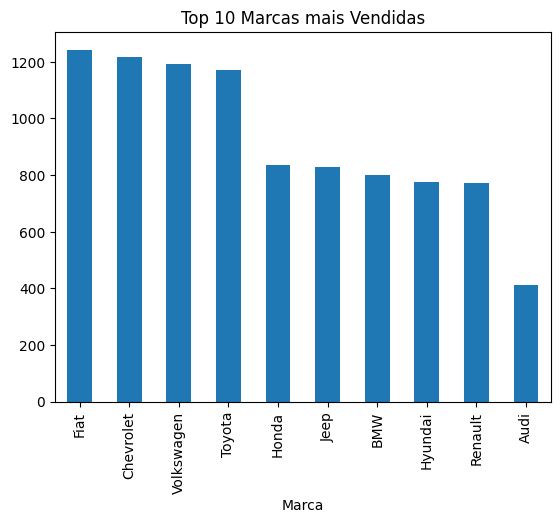

In [61]:
# 04: Quais foram as 10 marcas mais vendidas?
df['Marca'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Marcas mais Vendidas')
plt.show()
# A Fiat foi a marca mais vendida.

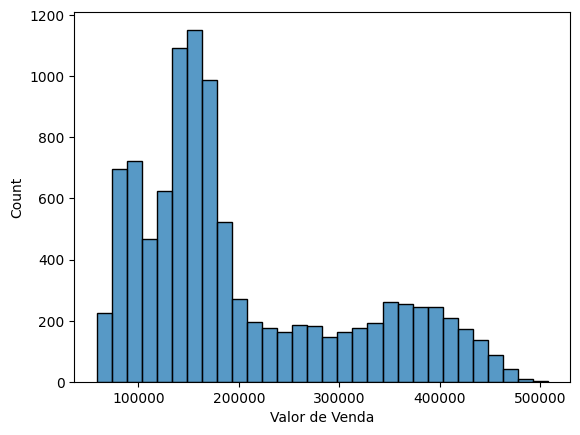

In [64]:
# 05: Analise exploratoria de valores comercializados
sns.histplot(df['Valor de Venda'], bins= 30)
# Veiculos entre 100.000 e 200.000 foram os mais vendidos.

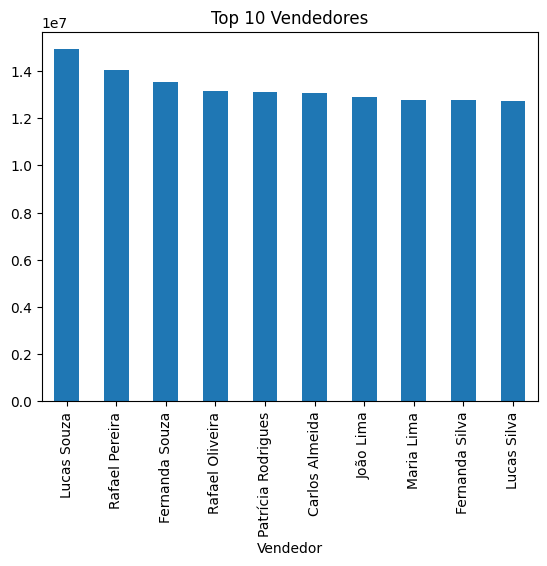

In [66]:
# 06: Quais sao os 10 melhores vendedores em nivel nacional?
top_vendedores = df.groupby('Vendedor')['Valor de Venda'].sum().sort_values(ascending= False).head(10)
top_vendedores.plot(kind='bar')
plt.title('Top 10 Vendedores')
plt.show()
# Lucas Souza foi o melhor vendedor das concessionarias.

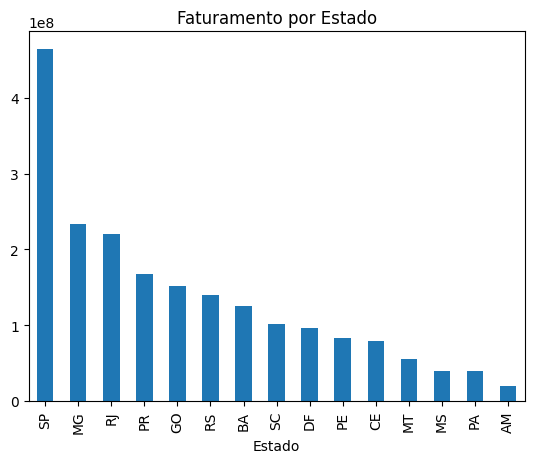

In [67]:
# 07: Qual o faturamento por estado?
faturamento_estado = df.groupby('Estado')['Valor de Venda'].sum().sort_values(ascending= False)
faturamento_estado.plot(kind='bar')
plt.title('Faturamento por Estado')
plt.show()
# Sao Paulo lidera o ranking de faturamento por estado, seguido de Minas Gerais, Rio de Janeiro, Parana, Goias e Rio Grande do Sul.

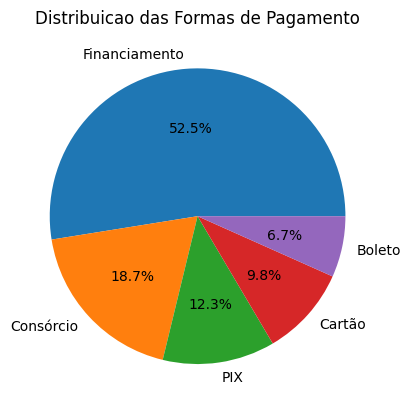

In [68]:
d# 08: Quais sao as formas de pagamento mais usadas?
df['Forma de Pagamento'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
)
plt.title('Distribuicao das Formas de Pagamento')
plt.ylabel('')
plt.show()

# Financiamento e a forma de pagamento mais utilizada, seguida de consorcio e pix.

In [70]:
# Transformando em csv
df.to_csv('vendas_concessionarias_sintetico.csv', index= False)